## 정형 데이터 미니퀘스트 1번

In [1]:
import pandas as pd

data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동'],
    '나이': [25, 30, 35, 28, 40],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO'],
    '연봉': [4000, 3500, 5000, 4200, 10000],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27']
}

df = pd.DataFrame(data)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   이름      5 non-null      str  
 1   나이      5 non-null      int64
 2   직업      5 non-null      str  
 3   연봉      5 non-null      int64
 4   가입일     5 non-null      str  
dtypes: int64(2), str(3)
memory usage: 332.0 bytes
None


## 정형 데이터 미니퀘스트 2번

In [2]:
import pandas as pd

data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

result = df[(df['나이'] >= 30) & (df['연봉'] <= 5000)]

print(result)

    이름  나이    직업    연봉         가입일
1  이영희  30   마케터  3500  2019-07-15
2  박민수  35   개발자  5000  2021-01-10
5  정지훈  50  디자이너  4600  2016-04-11


## 정형 데이터 미니퀘스트 3번

In [3]:
import pandas as pd

data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03',
             '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

df['가입일'] = pd.to_datetime(df['가입일'])

df.loc[df['가입일'].dt.year < 2019, '연봉'] = df.loc[df['가입일'].dt.year < 2019, '연봉'] * 1.1

average_salary = df['연봉'].mean()

print(df)
print(average_salary)

    이름  나이    직업     연봉        가입일
0  김철수  25   개발자   4000 2020-05-21
1  이영희  30   마케터   3500 2019-07-15
2  박민수  35   개발자   5000 2021-01-10
3  최지현  28  디자이너   4620 2018-11-03
4  홍길동  40   CEO  11000 2017-09-27
5  정지훈  50  디자이너   5060 2016-04-11
6  이지은  22   마케터   3300 2022-03-19
5211.428571428572


## 비정형데이터 미니퀘스트 1번

In [30]:
import pandas as pd
import json

data = [
    {"이름": "김철수", "나이": 25, "직업": "개발자", "연봉": 4000},
    {"이름": "이영희", "나이": 30, "직업": "마케터", "연봉": 3500},
    {"이름": "박민수", "나이": 35, "직업": "디자이너", "연봉": 4200}
]


df = pd.DataFrame(data)

print(df)

    이름  나이    직업    연봉
0  김철수  25   개발자  4000
1  이영희  30   마케터  3500
2  박민수  35  디자이너  4200


In [7]:
import pandas as pd
from io import StringIO

data = '''
[
    {"이름": "김철수", "나이": 25, "직업": "개발자", "연봉": 4000},
    {"이름": "이영희", "나이": 30, "직업": "마케터", "연봉": 3500},
    {"이름": "박민수", "나이": 35, "직업": "디자이너", "연봉": 4200}
]
'''

df = pd.read_json(StringIO(data))

print(df)

    이름  나이    직업    연봉
0  김철수  25   개발자  4000
1  이영희  30   마케터  3500
2  박민수  35  디자이너  4200


## 비정형데이터 미니퀘스트 2번

In [8]:
import re

text = "안녕하세요!!! 저는 AI 모델입니다. 12345 데이터를    정리해 보겠습니다."

cleaned_text = re.sub(r'[^가-힣\s]', '', text)
cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

print(cleaned_text)

안녕하세요 저는 모델입니다 데이터를 정리해 보겠습니다


## 비정형데이터 미니퀘스트 3번

In [9]:
import pandas as pd

text = "자연어 처리는 재미있다. 파이썬과 pandas를 활용하면 편리하다. 데이터 분석은 흥미롭다."

sentences = text.split('.')

result = []

for sentence in sentences:
    sentence = sentence.strip()
    
    if sentence:
        word_count = len(sentence.split())
        result.append({
            '문장': sentence,
            '단어수': word_count
        })

df = pd.DataFrame(result)

print(df)

                       문장  단어수
0            자연어 처리는 재미있다    3
1  파이썬과 pandas를 활용하면 편리하다    4
2            데이터 분석은 흥미롭다    3


## 막대그래프 미니퀘스트 1번

In [10]:
%pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 11.4 MB/s eta 0:00:00a 0:00:01
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 11.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


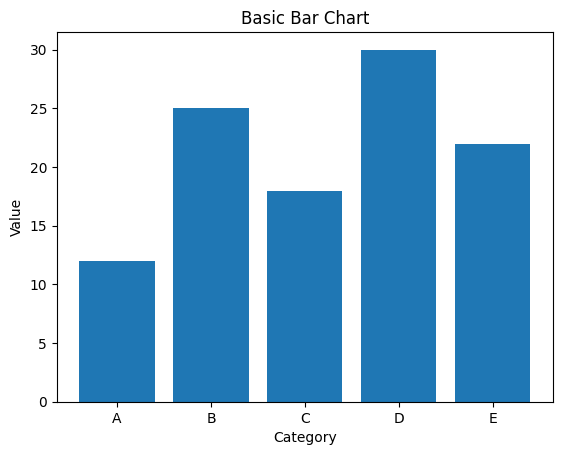

In [11]:
import matplotlib.pyplot as plt

# 샘플 데이터 생성
categories = ['A', 'B', 'C', 'D', 'E']
values = [12, 25, 18, 30, 22]

plt.bar(categories, values)

plt.title('Basic Bar Chart')
plt.xlabel('Category')
plt.ylabel('Value')

plt.show()

## 막대그래프 미니퀘스트 2번

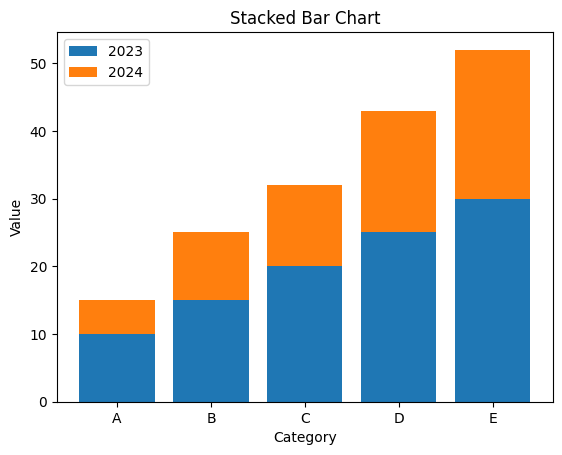

In [12]:
import matplotlib.pyplot as plt

# 샘플 데이터 생성
categories = ['A', 'B', 'C', 'D', 'E']
values_2023 = [10, 15, 20, 25, 30]
values_2024 = [5, 10, 12, 18, 22]

plt.bar(categories, values_2023, label='2023')
plt.bar(categories, values_2024, bottom=values_2023, label='2024')

plt.title('Stacked Bar Chart')
plt.xlabel('Category')
plt.ylabel('Value')
plt.legend()

plt.show()

## 막대그래프 미니퀘스트 3번

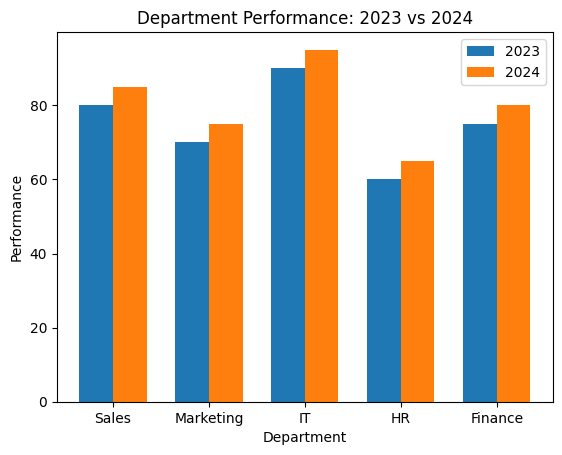

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 샘플 데이터 생성
departments = ['Sales', 'Marketing', 'IT', 'HR', 'Finance']
performance_2023 = [80, 70, 90, 60, 75]
performance_2024 = [85, 75, 95, 65, 80]

x = np.arange(len(departments))
width = 0.35

plt.bar(x - width/2, performance_2023, width, label='2023')
plt.bar(x + width/2, performance_2024, width, label='2024')

plt.title('Department Performance: 2023 vs 2024')
plt.xlabel('Department')
plt.ylabel('Performance')
plt.xticks(x, departments)
plt.legend()

plt.show()

## 히스토그램 미니퀘스트 1번

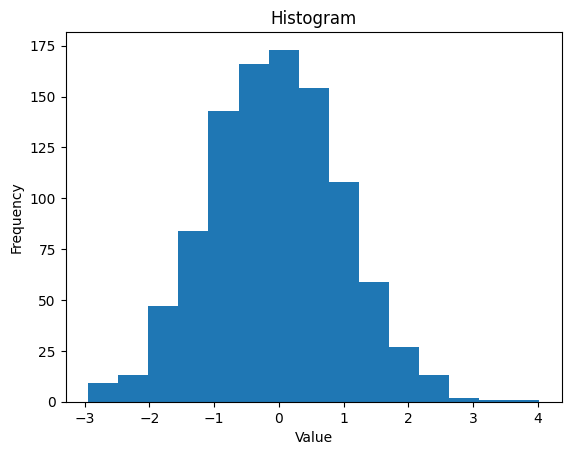

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 정규 분포를 따르는 1000개의 데이터 생성
data = np.random.randn(1000)

plt.hist(data, bins=15)

plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

## 히스토그램 미니퀘스트 2번

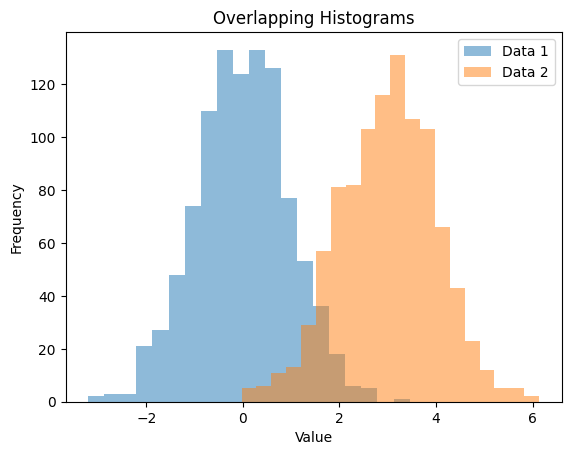

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 첫 번째 데이터셋: 평균 0, 표준편차 1
data1 = np.random.randn(1000)

# 두 번째 데이터셋: 평균 3, 표준편차 1
data2 = np.random.randn(1000) + 3

plt.hist(data1, bins=20, alpha=0.5, label='Data 1')
plt.hist(data2, bins=20, alpha=0.5, label='Data 2')

plt.title('Overlapping Histograms')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.show()

## 히스토그램 미니퀘스트 3번

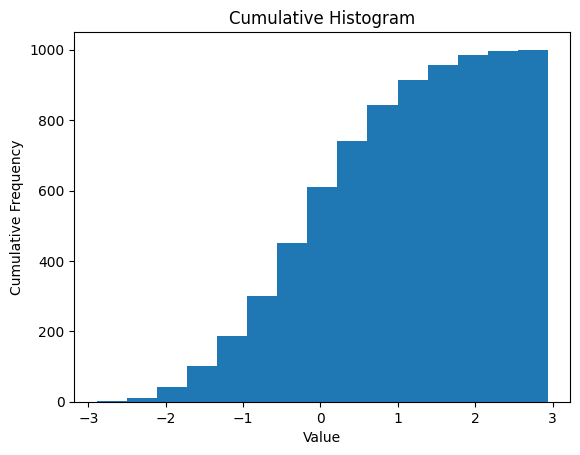

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 정규 분포를 따르는 1000개의 데이터 생성
data = np.random.randn(1000)

plt.hist(data, bins=15, cumulative=True)

plt.title('Cumulative Histogram')
plt.xlabel('Value')
plt.ylabel('Cumulative Frequency')

plt.show()

## 산점도 미니퀘스트 1번

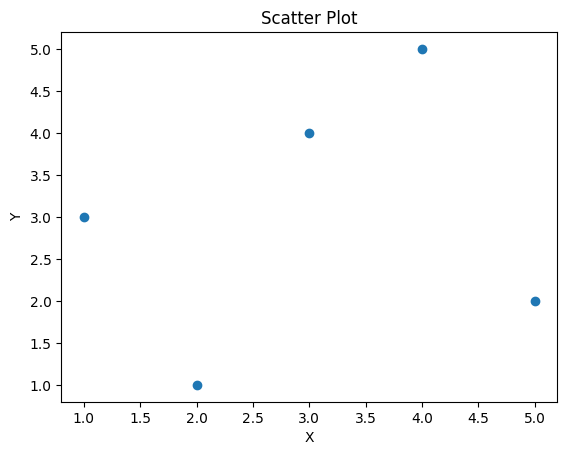

In [17]:
import matplotlib.pyplot as plt

# 데이터 생성
x = [1, 2, 3, 4, 5]
y = [3, 1, 4, 5, 2]

plt.scatter(x, y)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot')

plt.show()

## 산점도 미니퀘스트 2번

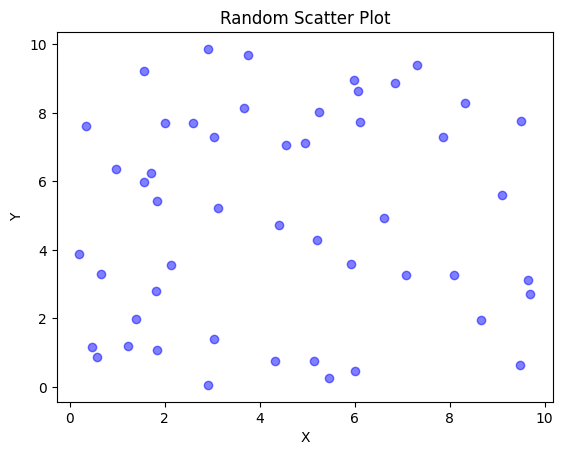

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 난수 데이터 생성
np.random.seed(42)
x = np.random.rand(50) * 10
y = np.random.rand(50) * 10

plt.scatter(x, y, color='blue', alpha=0.5)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Random Scatter Plot')

plt.show()

## 산점도 미니퀘스트 3번

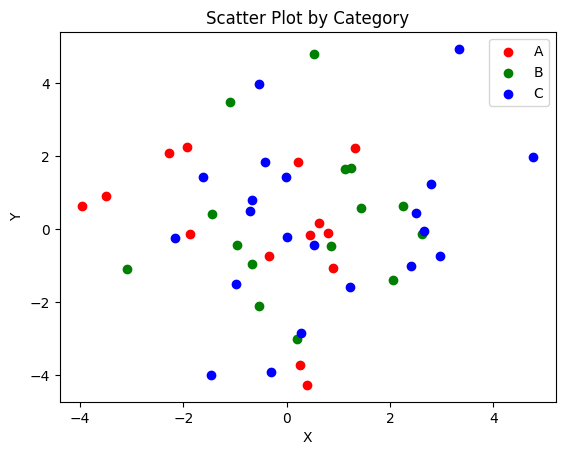

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성
np.random.seed(10)
x = np.random.randn(50) * 2
y = np.random.randn(50) * 2
categories = np.random.choice(['A', 'B', 'C'], size=50)

for category, color in zip(['A', 'B', 'C'], ['red', 'green', 'blue']):
    plt.scatter(
        x[categories == category],
        y[categories == category],
        label=category,
        color=color
    )

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot by Category')
plt.legend()

plt.show()

## 박스플롯 미니퀘스트 1번

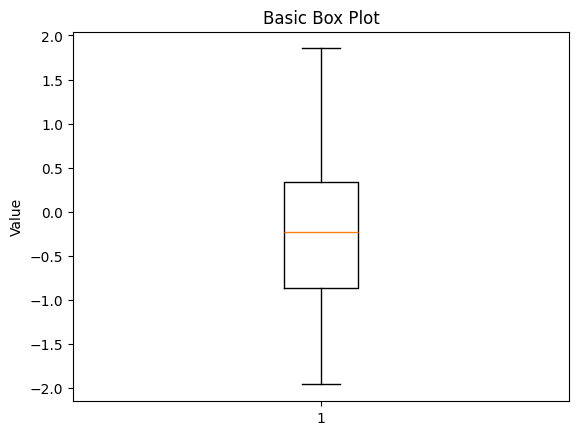

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 정규분포를 따르는 난수 50개 생성
np.random.seed(42)
data = np.random.randn(50)

plt.boxplot(data)

plt.title('Basic Box Plot')
plt.ylabel('Value')

plt.show()

## 박스플롯 미니퀘스트 2번

/var/folders/m2/4cpb0x850bs28bnbkzw98wqm0000gn/T/ipykernel_89772/689323092.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Group A', 'Group B', 'Group C'])


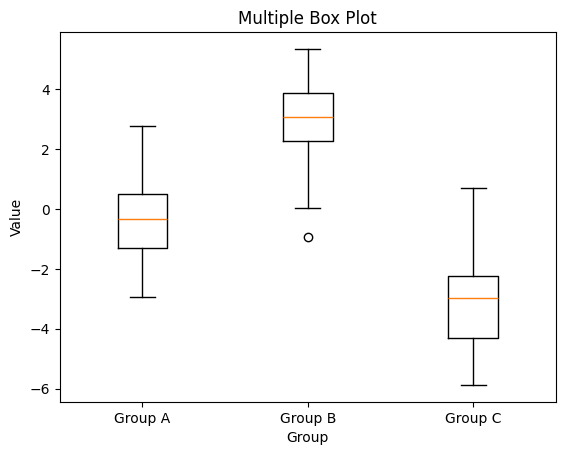

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 랜덤 데이터 생성
np.random.seed(42)
group_a = np.random.randn(50) * 1.5
group_b = np.random.randn(50) * 1.5 + 3
group_c = np.random.randn(50) * 1.5 - 3

data = [group_a, group_b, group_c]

plt.boxplot(data, labels=['Group A', 'Group B', 'Group C'])

plt.title('Multiple Box Plot')
plt.xlabel('Group')
plt.ylabel('Value')

plt.show()

## 박스플롯 미니퀘스트 3번

/var/folders/m2/4cpb0x850bs28bnbkzw98wqm0000gn/T/ipykernel_89772/2788400934.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


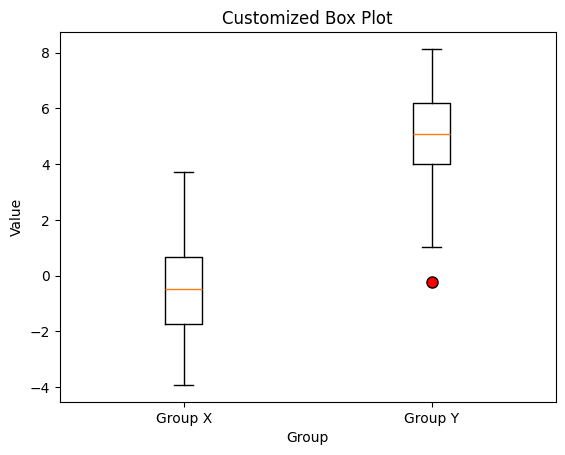

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 랜덤 데이터 생성
np.random.seed(42)
group_x = np.random.randn(50) * 2
group_y = np.random.randn(50) * 2 + 5

data = [group_x, group_y]

plt.boxplot(
    data,
    labels=['Group X', 'Group Y'],
    flierprops={
        'marker': 'o',
        'markersize': 8,
        'markerfacecolor': 'red',
        'markeredgecolor': 'black'
    }
)

plt.title('Customized Box Plot')
plt.xlabel('Group')
plt.ylabel('Value')

plt.show()

## 고급 다중 그래프 미니퀘스트 1번

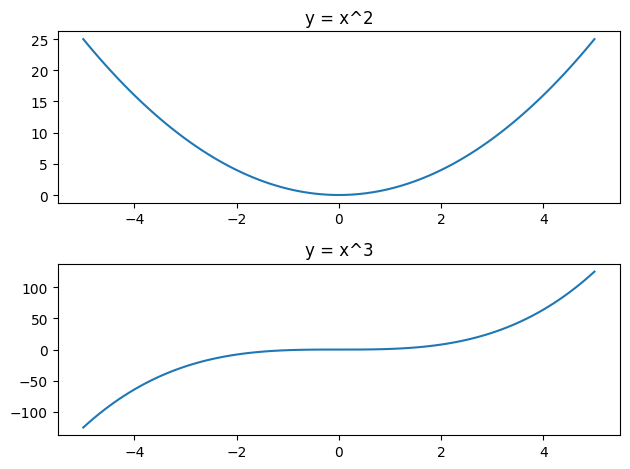

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성
x = np.linspace(-5, 5, 100)
y1 = x ** 2
y2 = x ** 3

fig, axes = plt.subplots(2, 1)

axes[0].plot(x, y1)
axes[0].set_title('y = x^2')

axes[1].plot(x, y2)
axes[1].set_title('y = x^3')

plt.tight_layout()
plt.show()

## 고급 다중 그래프 미니퀘스트 2번

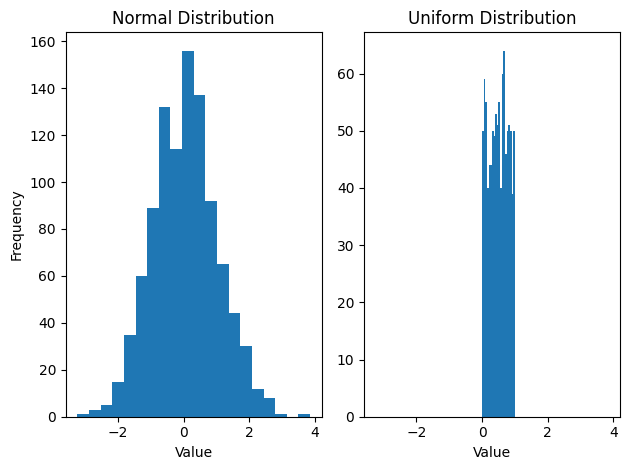

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성
normal_data = np.random.randn(1000)
uniform_data = np.random.rand(1000)

fig, axes = plt.subplots(1, 2, sharex=True)

axes[0].hist(normal_data, bins=20)
axes[0].set_title('Normal Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(uniform_data, bins=20)
axes[1].set_title('Uniform Distribution')
axes[1].set_xlabel('Value')

plt.tight_layout()
plt.show()

## 고급 다중 그래프 미니퀘스트 3번

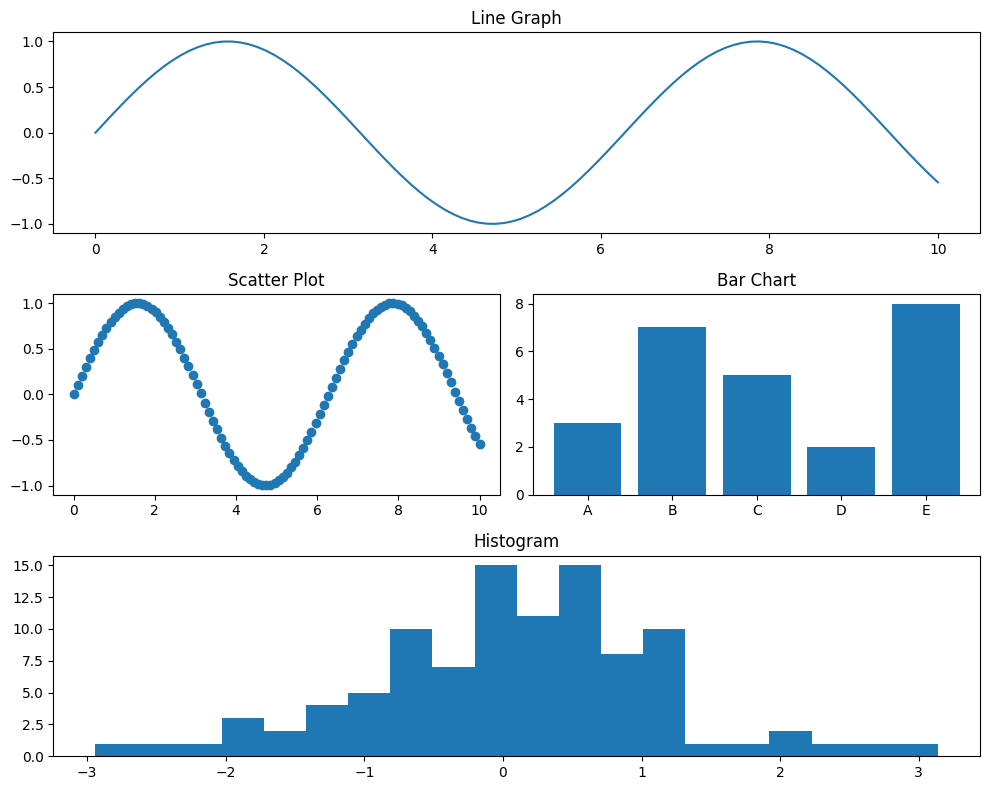

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 데이터 생성
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.random.randn(100)

categories = ['A', 'B', 'C', 'D', 'E']
values = [3, 7, 5, 2, 8]

fig = plt.figure(figsize=(10, 8))

gs = gridspec.GridSpec(3, 2)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, :])

ax1.plot(x, y1)
ax1.set_title('Line Graph')

ax2.scatter(x, y1)
ax2.set_title('Scatter Plot')

ax3.bar(categories, values)
ax3.set_title('Bar Chart')

ax4.hist(y2, bins=20)
ax4.set_title('Histogram')

plt.tight_layout()
plt.show()

## 벤 다이어그램 미니퀘스트 1번

In [ ]:
# 두 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

only_A = set_A - set_B

only_B = set_B - set_A

print("A에만 있는 요소:", only_A)
print("B에만 있는 요소:", only_B)

A에만 있는 요소: {'체리', '사과'}
B에만 있는 요소: {'포도', '수박'}


## 벤 다이어그램 미니퀘스트 2번

In [27]:
# 세 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}
set_C = {"망고", "수박", "딸기", "오렌지"}

# 각 집합만 단독으로 가지는 요소
only_A = set_A - set_B - set_C
only_B = set_B - set_A - set_C
only_C = set_C - set_A - set_B

# 두 집합 이상에 공통으로 들어가는 요소
intersection_AB = set_A & set_B
intersection_AC = set_A & set_C
intersection_BC = set_B & set_C
intersection_ABC = set_A & set_B & set_C

print("A만 가지는 요소 개수:", len(only_A))
print("B만 가지는 요소 개수:", len(only_B))
print("C만 가지는 요소 개수:", len(only_C))

print("A와 B의 교집합 개수:", len(intersection_AB))
print("A와 C의 교집합 개수:", len(intersection_AC))
print("B와 C의 교집합 개수:", len(intersection_BC))
print("A, B, C 전체 교집합 개수:", len(intersection_ABC))

A만 가지는 요소 개수: 2
B만 가지는 요소 개수: 1
C만 가지는 요소 개수: 2
A와 B의 교집합 개수: 2
A와 C의 교집합 개수: 1
B와 C의 교집합 개수: 2
A, B, C 전체 교집합 개수: 1


In [28]:
%pip install matplotlib-venn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 11.6 MB/s eta 0:00:00a 0:00:01
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=b22bf5832e607a812d13e076821fbd5fc5c629850770ccd13469dcfed1f6718e
  Stored in directory: /Users/jhmacpro/Library/Caches/pip/wheels/d1/5f/e6/771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib-venn
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [matplotlib-venn]

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 벤 다이어그램 미니퀘스트 3번

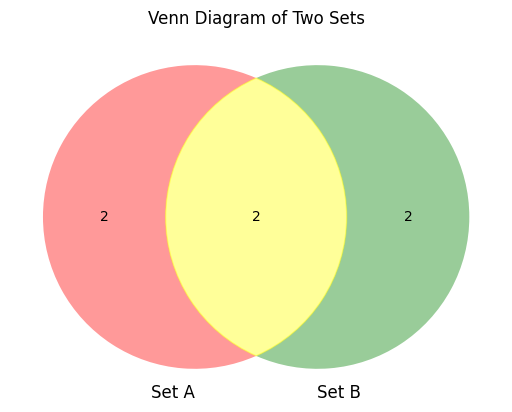

In [29]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# 두 개의 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

# 교집합 계산
intersection = set_A & set_B

# 벤 다이어그램 생성
v = venn2([set_A, set_B], set_labels=("Set A", "Set B"))

# 교집합이 2개 이상이면 교집합 영역을 노란색으로 지정
if len(intersection) >= 2:
    v.get_patch_by_id("11").set_color("yellow")

plt.title("Venn Diagram of Two Sets")
plt.show()

In [31]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 범주형 데이터 미니퀘스트 1번

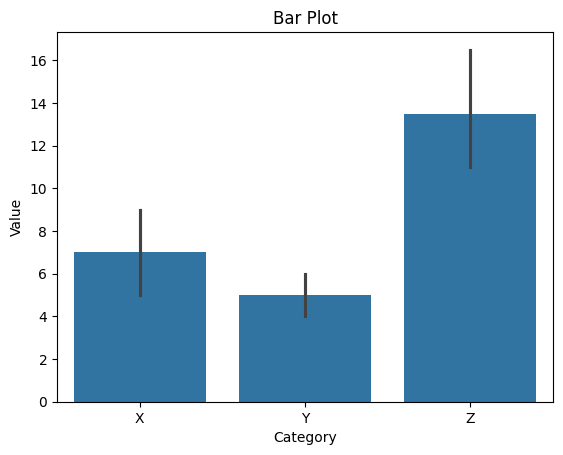

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 샘플 데이터 생성
data = pd.DataFrame({
    "카테고리": ["X", "X", "Y", "Y", "Z", "Z", "Z", "X", "Y", "Z"],
    "값": [5, 9, 4, 6, 12, 10, 14, 7, 5, 18]
})

sns.barplot(data=data, x="카테고리", y="값")

plt.title("Bar Plot")
plt.xlabel("Category")
plt.ylabel("Value")

plt.show()

## 범주형 데이터 미니퀘스트 2번

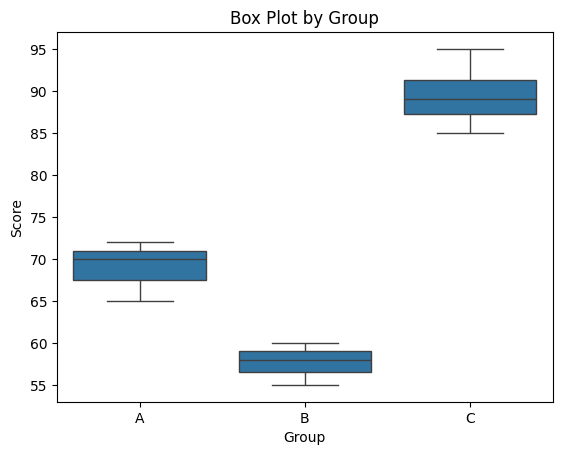

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 샘플 데이터 생성
data = pd.DataFrame({
    "group": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [65, 70, 55, 60, 90, 85, 95, 72, 58, 88]
})

sns.boxplot(data=data, x="group", y="score")

plt.title("Box Plot by Group")
plt.xlabel("Group")
plt.ylabel("Score")

plt.show()

## 범주형 데이터 미니퀘스트 3번

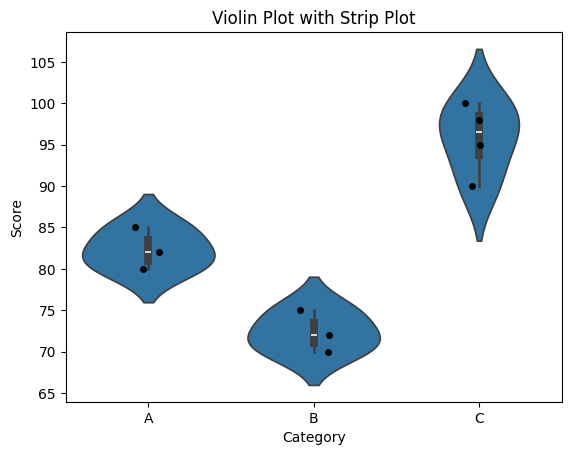

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 샘플 데이터 생성
data = pd.DataFrame({
    "category": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [80, 85, 70, 75, 95, 90, 100, 82, 72, 98]
})

sns.violinplot(data=data, x="category", y="score")
sns.stripplot(data=data, x="category", y="score", color="black", size=5)

plt.title("Violin Plot with Strip Plot")
plt.xlabel("Category")
plt.ylabel("Score")

plt.show()

## 연속형 데이터 미니퀘스트 1번

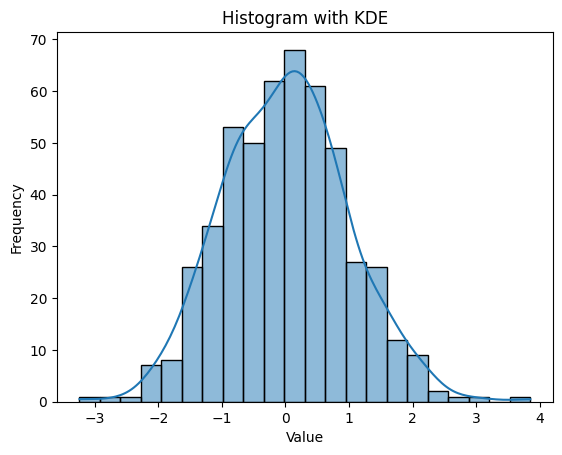

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 정규분포를 따르는 데이터 500개 생성
np.random.seed(42)
data = np.random.randn(500)

# 히스토그램 + KDE
sns.histplot(data, kde=True)

plt.title("Histogram with KDE")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

## 연속형 데이터 미니퀘스트 2번

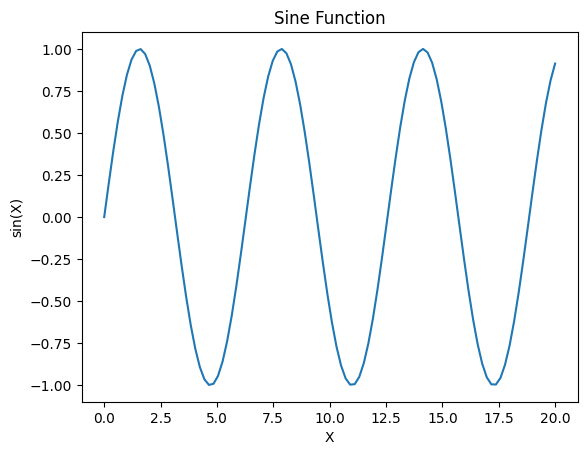

In [36]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# X 값 생성
x = np.linspace(0, 20, 100)
y = np.sin(x)

# 선 그래프
sns.lineplot(x=x, y=y)

plt.title("Sine Function")
plt.xlabel("X")
plt.ylabel("sin(X)")

plt.show()

## 연속형 데이터 미니퀘스트 3번

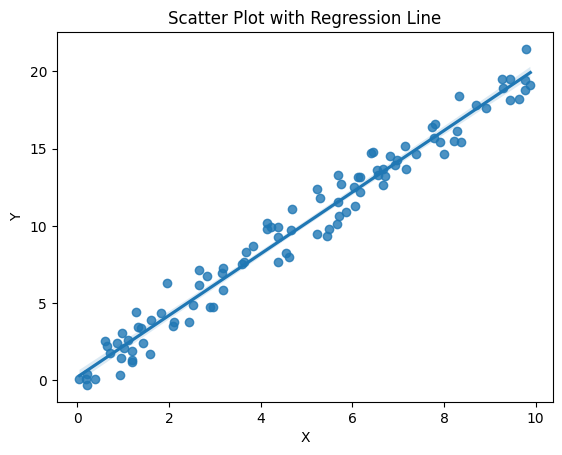

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 난수 생성
np.random.seed(0)
x = np.random.rand(100) * 10
y = 2 * x + np.random.randn(100)

# DataFrame 생성
df = pd.DataFrame({
    "x": x,
    "y": y
})

# 산점도 + 회귀선
sns.regplot(data=df, x="x", y="y")

plt.title("Scatter Plot with Regression Line")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

## 관계 데이터 미니퀘스트 1번

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

print(tips.head())
print(tips.columns)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')


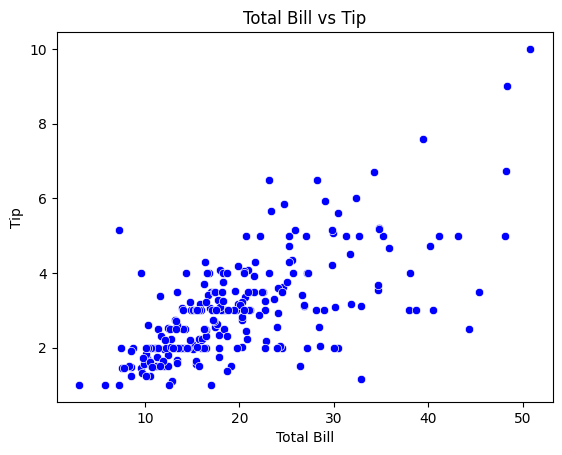

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    color="blue",
    marker="o"
)

plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()

## 관계 데이터 미니퀘스트 2번

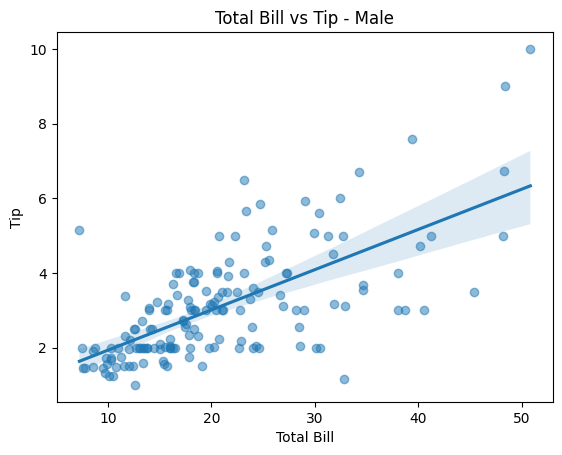

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

male_tips = tips[tips["sex"] == "Male"]

sns.regplot(
    data=male_tips,
    x="total_bill",
    y="tip",
    scatter_kws={"alpha": 0.5}
)

plt.title("Total Bill vs Tip - Male")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()

## 관계 데이터 미니퀘스트 3번

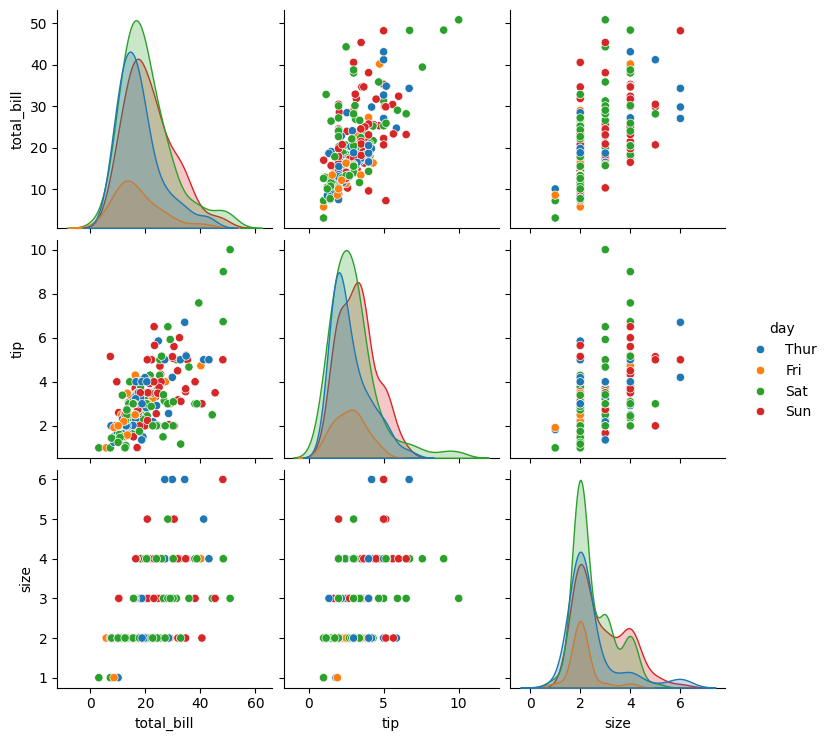

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

sns.pairplot(
    data=tips,
    vars=["total_bill", "tip", "size"],
    hue="day"
)

plt.show()

## 시계열 데이터 미니퀘스트 1번

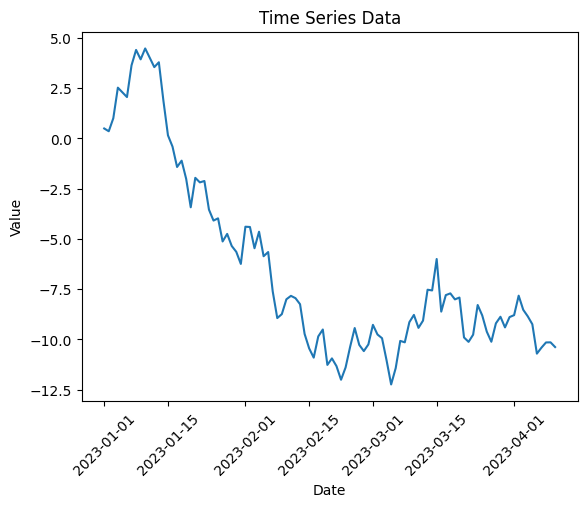

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

df = pd.DataFrame({
    "날짜": date_range,
    "값": values
})

plt.plot(df["날짜"], df["값"])

plt.title("Time Series Data")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=45)

plt.show()

## 시계열 데이터 미니퀘스트 2번

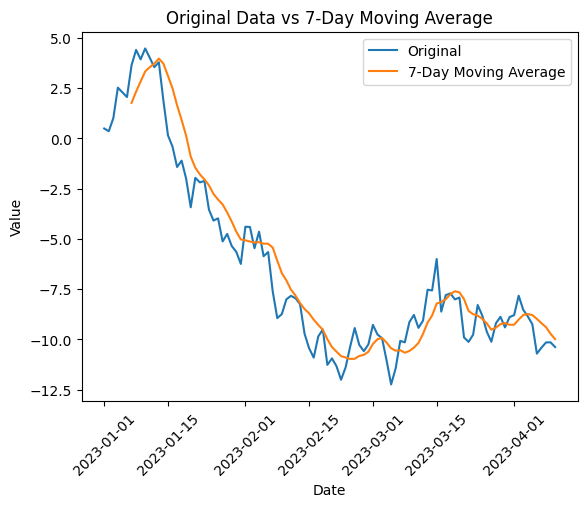

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

df = pd.DataFrame({
    "날짜": date_range,
    "값": values
})

# 7일 이동평균 계산
df["7일 이동평균"] = df["값"].rolling(window=7).mean()

# 그래프 그리기
plt.plot(df["날짜"], df["값"], label="Original")
plt.plot(df["날짜"], df["7일 이동평균"], label="7-Day Moving Average")

plt.title("Original Data vs 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend()

plt.show()

## 시계열 데이터 미니퀘스트 3번

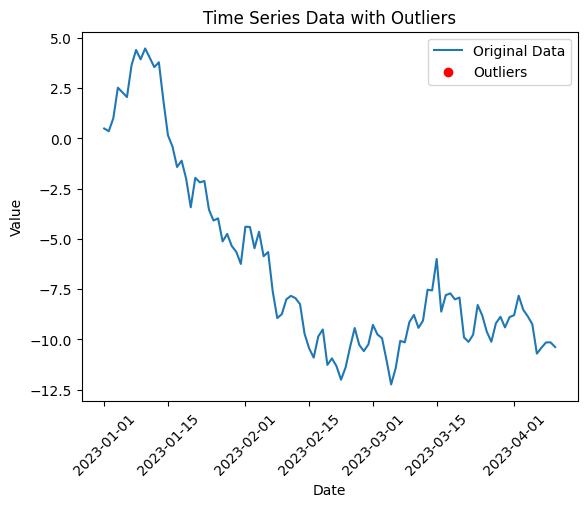

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

df = pd.DataFrame({
    "날짜": date_range,
    "값": values
})

# IQR 계산
Q1 = df["값"].quantile(0.25)
Q3 = df["값"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 탐지
outliers = df[(df["값"] < lower_bound) | (df["값"] > upper_bound)]

# 그래프 그리기
plt.plot(df["날짜"], df["값"], label="Original Data")
plt.scatter(outliers["날짜"], outliers["값"], label="Outliers", color="red")

plt.title("Time Series Data with Outliers")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend()

plt.show()

## 리샘플링 미니퀘스트 1번

In [8]:
import pandas as pd
import numpy as np

# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-05", freq="3h")

values = np.random.randn(len(date_rng))

df = pd.DataFrame({
    "값": values
}, index=date_rng)

# 하루 단위로 평균 계산
daily_mean = df.resample("D").mean()

print(daily_mean)

                   값
2024-01-01 -0.084685
2024-01-02  0.108810
2024-01-03  0.071744
2024-01-04 -0.083181
2024-01-05 -1.062304


## 리샘플링 미니퀘스트 2번

In [9]:
import pandas as pd
import numpy as np

# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-03", freq="3h")

values = np.random.randn(len(date_rng))

df = pd.DataFrame({
    "값": values
}, index=date_rng)

# 1시간 단위로 업샘플링 후 선형 보간
hourly_df = df.resample("h").asfreq()
hourly_interpolated = hourly_df.interpolate(method="linear")

print(hourly_interpolated)

                            값
2024-01-01 00:00:00  0.473592
2024-01-01 01:00:00  0.009254
2024-01-01 02:00:00 -0.455085
2024-01-01 03:00:00 -0.919424
2024-01-01 04:00:00 -0.096305
2024-01-01 05:00:00  0.726815
2024-01-01 06:00:00  1.549934
2024-01-01 07:00:00  0.772205
2024-01-01 08:00:00 -0.005524
2024-01-01 09:00:00 -0.783253
2024-01-01 10:00:00 -0.629523
2024-01-01 11:00:00 -0.475792
2024-01-01 12:00:00 -0.322062
2024-01-01 13:00:00  0.056465
2024-01-01 14:00:00  0.434991
2024-01-01 15:00:00  0.813517
2024-01-01 16:00:00  0.132057
2024-01-01 17:00:00 -0.549404
2024-01-01 18:00:00 -1.230864
2024-01-01 19:00:00 -0.744756
2024-01-01 20:00:00 -0.258648
2024-01-01 21:00:00  0.227460
2024-01-01 22:00:00  0.587354
2024-01-01 23:00:00  0.947248
2024-01-02 00:00:00  1.307143
2024-01-02 01:00:00  0.335601
2024-01-02 02:00:00 -0.635941
2024-01-02 03:00:00 -1.607483
2024-01-02 04:00:00 -1.010111
2024-01-02 05:00:00 -0.412739
2024-01-02 06:00:00  0.184634
2024-01-02 07:00:00  0.209717
2024-01-02

## 리샘플링 미니퀘스트 3번

In [10]:
import pandas as pd
import numpy as np

# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-07", freq="3h")

values = np.random.randn(len(date_rng))

df = pd.DataFrame({
    "값": values
}, index=date_rng)

# 하루 단위로 최소값과 최대값 계산
daily_min_max = df.resample("D").agg(["min", "max"])

print(daily_min_max)

                   값          
                 min       max
2024-01-01 -0.714351  1.865775
2024-01-02 -1.191303  1.158596
2024-01-03 -0.889514  1.896793
2024-01-04 -0.857158  2.720169
2024-01-05 -1.514847  0.714000
2024-01-06 -1.245739  0.856399
2024-01-07  0.058209  0.058209


## 이동평균 미니퀘스트 1번

In [11]:
import pandas as pd
import numpy as np

# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-05", freq="3h")

df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# datetime을 인덱스로 설정
df = df.set_index("datetime")

# 하루 단위 평균 계산
daily_mean = df.resample("D").mean()

print(daily_mean)

              value
datetime           
2024-01-01   84.125
2024-01-02   95.500
2024-01-03   86.250
2024-01-04  107.000
2024-01-05   81.000


## 이동평균 미니퀘스트 2번

In [12]:
import pandas as pd
import numpy as np

# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")

df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# 7일 지수 이동평균 계산
df["EMA_7"] = df["value"].ewm(span=7, adjust=False).mean()

print(df)

     datetime  value       EMA_7
0  2024-01-01    136  136.000000
1  2024-01-02    112  130.000000
2  2024-01-03    135  131.250000
3  2024-01-04    100  123.437500
4  2024-01-05     74  111.078125
5  2024-01-06    107  110.058594
6  2024-01-07    112  110.543945
7  2024-01-08    111  110.657959
8  2024-01-09     71  100.743469
9  2024-01-10    107  102.307602
10 2024-01-11    107  103.480701
11 2024-01-12    135  111.360526
12 2024-01-13     98  108.020395
13 2024-01-14    101  106.265296
14 2024-01-15     91  102.448972
15 2024-01-16    119  106.586729
16 2024-01-17     64   95.940047
17 2024-01-18    103   97.705035
18 2024-01-19    109  100.528776
19 2024-01-20    146  111.896582


## 이동평균 미니퀘스트 3번

In [13]:
import pandas as pd
import numpy as np

# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")

df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# 7일 단순 이동평균 계산
df["SMA_7"] = df["value"].rolling(window=7).mean()

# 이동평균보다 ±20% 이상 차이 나는 데이터 필터링
result = df[
    (df["value"] >= df["SMA_7"] * 1.2) |
    (df["value"] <= df["SMA_7"] * 0.8)
]

print(result)

     datetime  value       SMA_7
6  2024-01-07    145   91.285714
7  2024-01-08    143  103.571429
9  2024-01-10    148  108.285714
11 2024-01-12     89  111.428571
13 2024-01-14     65  106.571429
14 2024-01-15     62   95.000000
18 2024-01-19    112   79.000000


## 금융데이터 미니퀘스트 1번

In [14]:
import pandas as pd

data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Open': [100, 102, 105, 103, 108, 107, 110, 112, 115, 118],
    'High': [102, 106, 108, 107, 110, 109, 112, 115, 117, 120],
    'Low': [98, 100, 103, 101, 106, 105, 108, 110, 113, 116],
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119],
    'Volume': [1000, 1200, 1500, 1300, 1600, 1400, 1700, 1800, 1900, 2000]
}

df = pd.DataFrame(data)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10 non-null     datetime64[us]
 1   Open    10 non-null     int64         
 2   High    10 non-null     int64         
 3   Low     10 non-null     int64         
 4   Close   10 non-null     int64         
 5   Volume  10 non-null     int64         
dtypes: datetime64[us](1), int64(5)
memory usage: 612.0 bytes
None


## 금융데이터 미니퀘스트 2번

In [15]:
import pandas as pd

data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119]
}

df = pd.DataFrame(data)

df['SMA_5'] = df['Close'].rolling(window=5).mean()
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()

print(df)

        Date  Close  SMA_5       EMA_5
0 2024-01-01    101    NaN  101.000000
1 2024-01-02    104    NaN  102.000000
2 2024-01-03    106    NaN  103.333333
3 2024-01-04    105    NaN  103.888889
4 2024-01-05    109  105.0  105.592593
5 2024-01-06    108  106.4  106.395062
6 2024-01-07    111  107.8  107.930041
7 2024-01-08    113  109.2  109.620027
8 2024-01-09    116  111.4  111.746685
9 2024-01-10    119  113.4  114.164457


## 금융데이터 미니퀘스트 3번

In [16]:
import pandas as pd
import numpy as np

# 샘플 금융 데이터 생성
date_rng = pd.date_range(start='2024-01-01', periods=30, freq='D')
close_prices = np.random.uniform(100, 200, size=len(date_rng))

df = pd.DataFrame({
    'Date': date_rng,
    'Close': close_prices
})

df = df.set_index('Date')

weekly_result = df['Close'].resample('7D').agg(['mean', 'std'])

print(weekly_result)

                  mean        std
Date                             
2024-01-01  149.233346  36.053794
2024-01-08  139.770402  23.680738
2024-01-15  155.459153  24.114977
2024-01-22  136.202316  38.757959
2024-01-29  128.600399  26.611233


## 정규분포 미니퀘스트 1번

In [17]:
import numpy as np

# 평균 60, 표준편차 15인 정규분포에서 500개 데이터 생성
data = np.random.normal(loc=60, scale=15, size=500)

# 기본 통계 정보 출력
print("평균:", np.mean(data))
print("표준편차:", np.std(data))
print("최소값:", np.min(data))
print("최대값:", np.max(data))

평균: 59.516355229483814
표준편차: 14.907752003044106
최소값: 11.380989898963911
최대값: 106.18321212682856


## 정규분포 미니퀘스트 2번

In [18]:
from scipy.stats import norm

# 평균과 표준편차 설정
mean = 50
std = 10
x = 65

# PDF 계산
pdf_value = norm.pdf(x, loc=mean, scale=std)

print("PDF 값:", pdf_value)

PDF 값: 0.012951759566589175


## 정규분포 미니퀘스트 3번

In [19]:
from scipy.stats import norm

# 평균과 표준편차 설정
mean = 70
std = 8

# 1. x=80 이하일 확률 계산
prob_below_80 = norm.cdf(80, loc=mean, scale=std)

# 2. 상위 5%에 해당하는 점수 계산
top_5_score = norm.ppf(0.95, loc=mean, scale=std)

print("80 이하일 확률:", prob_below_80)
print("상위 5%에 해당하는 점수:", top_5_score)

80 이하일 확률: 0.8943502263331446
상위 5%에 해당하는 점수: 83.15882901561177


## 기술통계 미니퀘스트 1번

In [20]:
import numpy as np
import pandas as pd

# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)

df = pd.DataFrame(data, columns=["value"])

mean_value = df["value"].mean()
median_value = df["value"].median()

difference = mean_value - median_value

print("평균:", mean_value)
print("중앙값:", median_value)
print("평균과 중앙값의 차이:", difference)

평균: 48.96153482605907
중앙값: 48.73043708220287
평균과 중앙값의 차이: 0.2310977438562034


## 기술통계 미니퀘스트 2번

In [21]:
import numpy as np
import pandas as pd

# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)

df = pd.DataFrame(data, columns=["value"])

# IQR 계산
Q1 = df["value"].quantile(0.25)
Q3 = df["value"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거
filtered_df = df[
    (df["value"] >= lower_bound) &
    (df["value"] <= upper_bound)
]

# 평균 비교
original_mean = df["value"].mean()
filtered_mean = filtered_df["value"].mean()

print("원래 데이터 평균:", original_mean)
print("이상치 제거 후 평균:", filtered_mean)
print("제거된 이상치 개수:", len(df) - len(filtered_df))

원래 데이터 평균: 48.96153482605907
이상치 제거 후 평균: 49.215665996432364
제거된 이상치 개수: 1


## 기술통계 미니퀘스트 3번

In [22]:
import numpy as np
import pandas as pd

# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)

df = pd.DataFrame(data, columns=["value"])

skewness = df["value"].skew()
kurtosis = df["value"].kurt()

print("왜도:", skewness)
print("첨도:", kurtosis)

왜도: -0.17794814262595568
첨도: -0.10097745347286491


## 가설 검정 미니퀘스트 1번

In [23]:
import numpy as np
from scipy import stats

# 샘플 데이터 생성
np.random.seed(42)
sample_data = np.random.normal(loc=50, scale=5, size=30)

# 단일 표본 t-검정
t_stat, p_value = stats.ttest_1samp(sample_data, popmean=52)

print("샘플 평균:", np.mean(sample_data))
print("t-statistic:", t_stat)
print("p-value:", p_value)

# 유의수준 0.05 기준 판단
alpha = 0.05

if p_value < alpha:
    print("귀무가설 기각: 평균은 52와 유의미한 차이가 있습니다.")
else:
    print("귀무가설 기각 실패: 평균은 52와 유의미한 차이가 있다고 보기 어렵습니다.")

샘플 평균: 49.05926552074481
t-statistic: -3.5793224601074907
p-value: 0.001236725827924849
귀무가설 기각: 평균은 52와 유의미한 차이가 있습니다.


## 가설 검정 미니퀘스트 2번

In [24]:
import numpy as np
from scipy import stats

# 관측값
observed = np.array([50, 60, 90])

# 기대값
expected = np.array([66, 66, 66]) * (observed.sum() / np.sum([66, 66, 66]))

# 카이제곱 검정
chi_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print("관측값:", observed)
print("기대값:", expected)
print("chi-square statistic:", chi_stat)
print("p-value:", p_value)

# 유의수준 0.05 기준 판단
alpha = 0.05

if p_value < alpha:
    print("귀무가설 기각: 관측값과 기대값 사이에 유의미한 차이가 있습니다.")
else:
    print("귀무가설 기각 실패: 관측값과 기대값 사이에 유의미한 차이가 있다고 보기 어렵습니다.")

관측값: [50 60 90]
기대값: [66.66666667 66.66666667 66.66666667]
chi-square statistic: 13.0
p-value: 0.0015034391929775717
귀무가설 기각: 관측값과 기대값 사이에 유의미한 차이가 있습니다.


## 가설 검정 미니퀘스트 3번

In [25]:
import numpy as np
from scipy import stats

# 샘플 데이터 생성
np.random.seed(42)

group_1 = np.random.normal(loc=50, scale=10, size=30)
group_2 = np.random.normal(loc=55, scale=10, size=30)
group_3 = np.random.normal(loc=60, scale=10, size=30)

# 일원분산분석 ANOVA
f_stat, p_value = stats.f_oneway(group_1, group_2, group_3)

print("Group 1 평균:", np.mean(group_1))
print("Group 2 평균:", np.mean(group_2))
print("Group 3 평균:", np.mean(group_3))
print("F-statistic:", f_stat)
print("p-value:", p_value)

# 유의수준 0.05 기준 판단
alpha = 0.05

if p_value < alpha:
    print("귀무가설 기각: 적어도 하나의 그룹 평균은 유의미하게 다릅니다.")
else:
    print("귀무가설 기각 실패: 그룹 평균들이 유의미하게 다르다고 보기 어렵습니다.")

Group 1 평균: 48.118531041489625
Group 2 평균: 53.788375297100565
Group 3 평균: 60.128847724722235
F-statistic: 12.20952551797281
p-value: 2.1200748140506923e-05
귀무가설 기각: 적어도 하나의 그룹 평균은 유의미하게 다릅니다.


## 통계적 시각화 미니퀘스트 1번

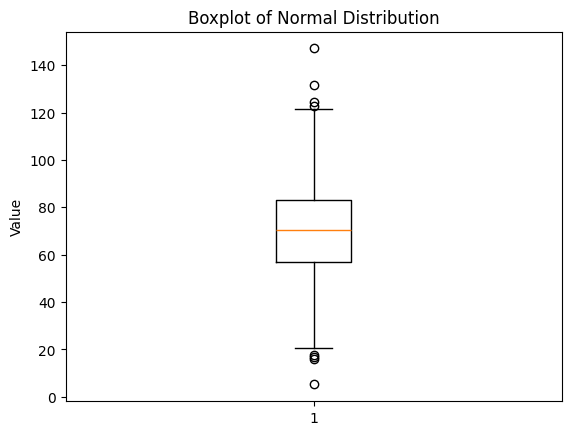

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=70, scale=20, size=1000)

# 박스플롯 그리기
plt.boxplot(data)

plt.title("Boxplot of Normal Distribution")
plt.ylabel("Value")

plt.show()

## 통계적 시각화 미니퀘스트 2번

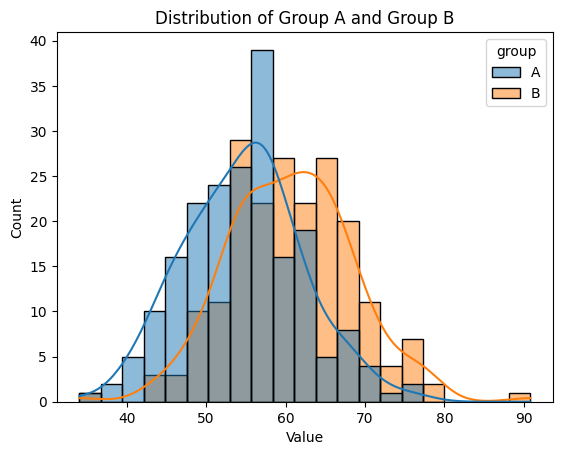

Group A 평균: 54.67383227862332
Group B 평균: 60.68694549519101
t-statistic: -7.834368710058932
p-value: 4.3352883078341774e-14
귀무가설 기각: 두 그룹의 평균 차이는 통계적으로 유의미합니다.


In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 데이터 생성
np.random.seed(42)
group_A = np.random.normal(loc=55, scale=8, size=200)
group_B = np.random.normal(loc=60, scale=8, size=200)

# 시각화를 위한 DataFrame 생성
df = pd.DataFrame({
    "value": np.concatenate([group_A, group_B]),
    "group": ["A"] * len(group_A) + ["B"] * len(group_B)
})

# 히스토그램 + KDE 시각화
sns.histplot(
    data=df,
    x="value",
    hue="group",
    kde=True,
    alpha=0.5
)

plt.title("Distribution of Group A and Group B")
plt.xlabel("Value")
plt.ylabel("Count")

plt.show()

# 독립표본 t-검정
t_stat, p_value = stats.ttest_ind(group_A, group_B)

print("Group A 평균:", np.mean(group_A))
print("Group B 평균:", np.mean(group_B))
print("t-statistic:", t_stat)
print("p-value:", p_value)

# 유의수준 0.05 기준 해석
alpha = 0.05

if p_value < alpha:
    print("귀무가설 기각: 두 그룹의 평균 차이는 통계적으로 유의미합니다.")
else:
    print("귀무가설 기각 실패: 두 그룹의 평균 차이가 유의미하다고 보기 어렵습니다.")

## 통계적 시각화 미니퀘스트 3번

          Ad_A  Ad_B
Click      120   150
No Click   380   350
chi-square statistic: 4.266869609335362
p-value: 0.038862461685793714
자유도: 1
기대 빈도:
[[135. 135.]
 [365. 365.]]


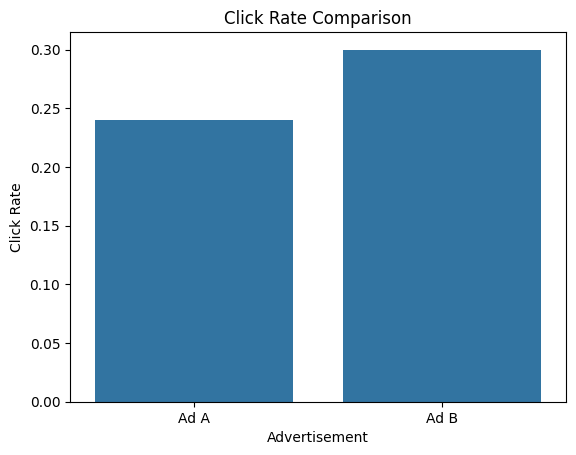

귀무가설 기각: 광고 A와 광고 B의 클릭률 차이는 통계적으로 유의미합니다.


In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 관측 데이터 생성
observed_data = pd.DataFrame({
    "Ad_A": [120, 380],
    "Ad_B": [150, 350]
}, index=["Click", "No Click"])

print(observed_data)

# 카이제곱 검정
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed_data)

print("chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("자유도:", dof)
print("기대 빈도:")
print(expected)

# 클릭률 계산
click_rate_df = pd.DataFrame({
    "Ad": ["Ad A", "Ad B"],
    "Click Rate": [120 / 500, 150 / 500]
})

# 클릭률 barplot
sns.barplot(
    data=click_rate_df,
    x="Ad",
    y="Click Rate"
)

plt.title("Click Rate Comparison")
plt.xlabel("Advertisement")
plt.ylabel("Click Rate")

plt.show()

# 유의수준 0.05 기준 해석
alpha = 0.05

if p_value < alpha:
    print("귀무가설 기각: 광고 A와 광고 B의 클릭률 차이는 통계적으로 유의미합니다.")
else:
    print("귀무가설 기각 실패: 광고 A와 광고 B의 클릭률 차이가 유의미하다고 보기 어렵습니다.")

## 추가 과제 3번

## 시계열 데이터를 입수하여 시각화하세요. (ai로 데이터 생성해보기)

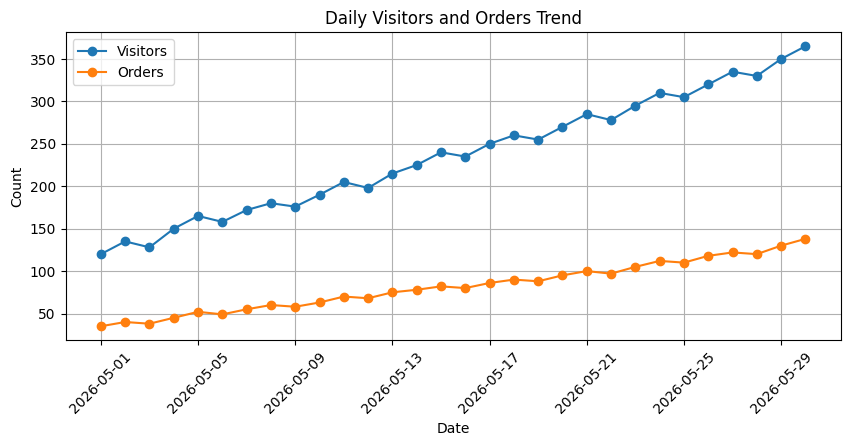

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

time_data = {
    "Date": [
        "2026-05-01", "2026-05-02", "2026-05-03", "2026-05-04", "2026-05-05",
        "2026-05-06", "2026-05-07", "2026-05-08", "2026-05-09", "2026-05-10",
        "2026-05-11", "2026-05-12", "2026-05-13", "2026-05-14", "2026-05-15",
        "2026-05-16", "2026-05-17", "2026-05-18", "2026-05-19", "2026-05-20",
        "2026-05-21", "2026-05-22", "2026-05-23", "2026-05-24", "2026-05-25",
        "2026-05-26", "2026-05-27", "2026-05-28", "2026-05-29", "2026-05-30"
    ],
    "Visitors": [
        120, 135, 128, 150, 165,
        158, 172, 180, 176, 190,
        205, 198, 215, 225, 240,
        235, 250, 260, 255, 270,
        285, 278, 295, 310, 305,
        320, 335, 330, 350, 365
    ],
    "Orders": [
        35, 40, 38, 45, 52,
        49, 55, 60, 58, 63,
        70, 68, 75, 78, 82,
        80, 86, 90, 88, 95,
        100, 97, 105, 112, 110,
        118, 122, 120, 130, 138
    ]
}

time_df = pd.DataFrame(time_data)

time_df["Date"] = pd.to_datetime(time_df["Date"])

plt.figure(figsize=(10, 4))
plt.plot(time_df["Date"], time_df["Visitors"], marker="o", label="Visitors")
plt.plot(time_df["Date"], time_df["Orders"], marker="o", label="Orders")
plt.title("Daily Visitors and Orders Trend")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()